In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import pandas as pd

from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u

from darksirenpop.utilities.utils import make_nice_plots

make_nice_plots()


In [2]:
hdul = fits.open('/home/lucas/Documents/PhD/agn_data/dr16q_prop_May01_2024.fits.gz')
hdul.info()


Filename: /home/lucas/Documents/PhD/agn_data/dr16q_prop_May01_2024.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    238   750414R x 115C   [18A, K, K, K, D, D, 20A, 10A, D, 12A, D, D, D, D, D, 5D, 5D, 2D, 3D, 3D, D, D, 3D, 3D, D, D, D, D, D, D, D, D, D, D, D, D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 2D, 2D, 2D, 2D, 2D, 2D, 2D, 2D, 2D, 2D, D, D, D, D, D, D, D, D, D, D, D, D, 8D, 8D, D]   
  2                1 BinTableHDU    188   750414R x 90C   [5D, 5D, 5D, E, D, D, D, D, D, D, D, D, J, J, J, 5E, 5D, 5E, 5D, 5E, D, D, I, D, D, D, D, I, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E, E, I, E, E, E, E, E, E, E, E, E, I, I, D, D, D, D, D, D, J, D, D, D, J, D, D, D, J, D, 21A, D, D, E, E, D, K, D, D, E, E, E,

In [3]:
hdr1 = hdul[1].header
hdr2 = hdul[2].header

print(hdr1.keys)
print(hdr2.keys)

<bound method Header.keys of XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 3436 / length of dimension 1                          
NAXIS2  =               750414 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                  115 / number of table fields                         
TTYPE1  = 'SDSS_NAME'                                                           
TFORM1  = '18A     '                                                            
TTYPE2  = 'PLATE   '                                                            
TFORM2  = 'K       '                                                            

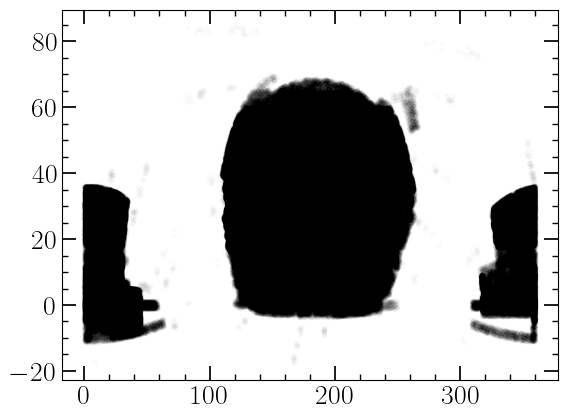

In [4]:
ra_sdss = hdul[1].data['RA']
dec_sdss = hdul[1].data['DEC']

plt.scatter(ra_sdss, dec_sdss, marker='.', alpha=0.01, color='black')
plt.show()


3089


/tmp/ipykernel_1305458/1914782322.py:4: RuntimeWarning: divide by zero encountered in divide
  mask = (z_sys > 0) & (z_sys_err > 0) & (z_sys_err < 0.02) & (z_sys_err / z_sys < 0.01)


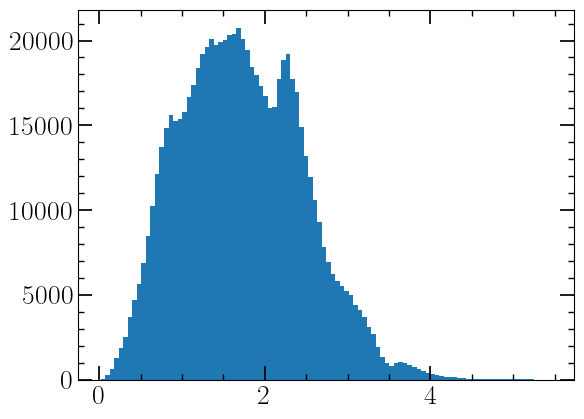

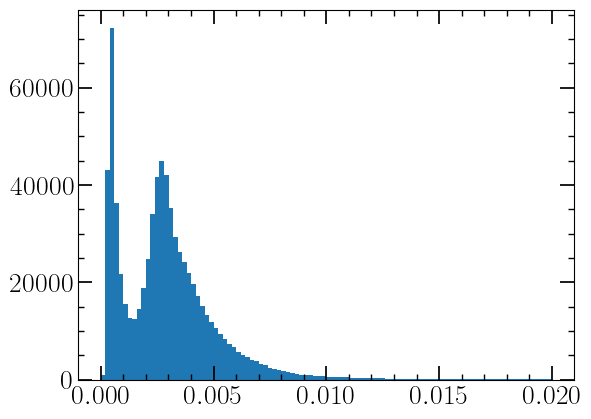

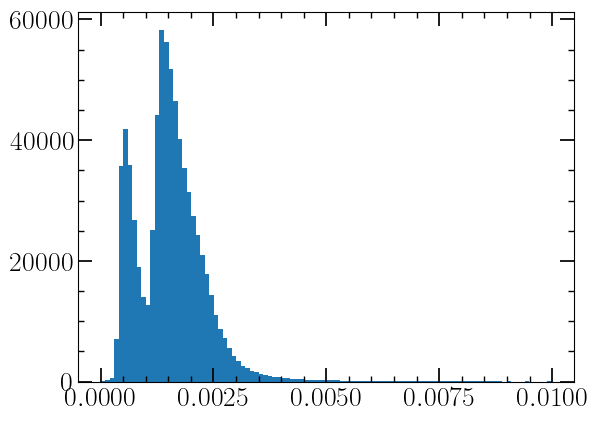

In [5]:
z_sys = hdul[1].data['Z_SYS']
z_sys_err = hdul[1].data['Z_SYS_ERR']

mask = (z_sys > 0) & (z_sys_err > 0) & (z_sys_err < 0.02) & (z_sys_err / z_sys < 0.01)
print(np.sum(~mask))

plt.hist(z_sys[mask], bins=100)
plt.show()

plt.hist(z_sys_err[mask], bins=100)
plt.show()

plt.hist(z_sys_err[mask] / z_sys[mask], bins=100)
plt.show()


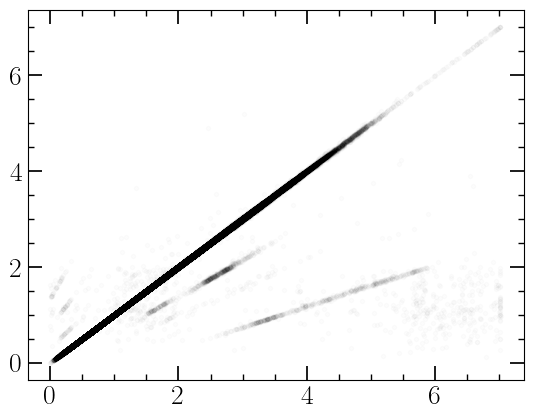

24938


In [6]:
z_sdss = hdul[1].data['Z_DR16Q']
mask = (z_sdss > 0) & (z_sys > 0)
plt.scatter(z_sdss[mask], z_sys[mask], marker = '.', color='black', alpha=0.01)
plt.show()

nonzero_diff = abs(z_sdss[mask] - z_sys[mask]) > 0.01
print(np.sum(nonzero_diff))
# plt.hist(z_sdss[mask][nonzero_diff] - z_sys[mask][nonzero_diff], bins=100)
# plt.show()



In [7]:
QUAIA_LUM_THRESH = 0
QUAIA_PATH = "/home/lucas/Documents/PhD/agn_data/quaia_zleq3_withlumcorr.csv"  # "/home/lucas/Documents/PhD/agn_data/Quaia_z15.csv"
df = pd.read_csv(QUAIA_PATH)
cols = ["redshift_quaia", "redshift_quaia_err", "ra", "dec", "b", "loglbol_corr", "log10_bollum"]
quaia = df[cols]

sel = quaia['loglbol_corr'] > QUAIA_LUM_THRESH

z_quaia = quaia['redshift_quaia'].loc[sel]
z_err_quaia = quaia['redshift_quaia_err'].loc[sel]
ra_quaia = quaia['ra'].loc[sel].to_numpy()
dec_quaia = quaia['dec'].loc[sel].to_numpy()
print(len(z_quaia))

1259043


283253
1.9308228208383929


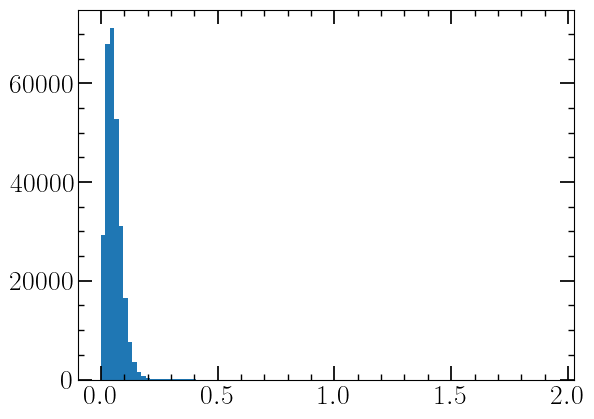

In [8]:
# Make angular crossmatch between SDSS and Quaia

sdss_skycoord = SkyCoord(ra=ra_sdss * u.degree, dec=dec_sdss * u.degree)
quaia_skycoord = SkyCoord(ra=ra_quaia *  u.degree, dec=dec_quaia * u.degree)

max_sep = 2.0 * u.arcsec

idx_sdss, idx_quaia, d2d, _ = quaia_skycoord.search_around_sky(sdss_skycoord, max_sep)
sep_constraint = d2d < max_sep
print(np.sum(sep_constraint))
print(np.max(d2d.to(u.arcsec).value))

plt.hist(d2d[sep_constraint].to(u.arcsec).value, bins=100)
plt.show()


In [9]:
# Get crossmatch of catalogs as new catalogs

sdss_match = hdul[1].data[idx_sdss]
quaia_match = quaia.iloc[idx_quaia]
print(len(sdss_match), len(quaia_match))


283253 283253


In [10]:
# from redshift_utils import *
# from utils import *
# from scipy.stats import truncnorm

# # r, t, p = uniform_shell_sampler(rmin = 0, rmax = COSMO.comoving_distance(10).value, n_samps=int(1e6))
# # z = fast_z_at_value(COSMO.comoving_distance, r * u.Mpc)
# z = truncnorm.rvs(loc=1.3, scale=0.2, a = (0 - 1.3) / 0.2, b = (1.5 - 1.3) / 0.2, size=int(1e6))

# z_meas = truncnorm.rvs(loc=z, scale=0.3, a = (0 - z) / 0.3, b = (1.5 - z) / 0.3)
# edges = np.linspace(0, 2, 100)

# plt.figure()
# h, bins, _ = plt.hist(z, bins=edges, histtype='step', linewidth=2)
# h2, _, _ = plt.hist(z_meas, bins=edges, histtype='step', linewidth=2)
# plt.show()

# plt.figure()
# plt.plot((edges[:-1] + edges[1:]) / 2, h2/h)
# plt.hlines(1, 0, 11, linestyles='dashed', colors='black')
# plt.xlim(0, 1)
# plt.show()



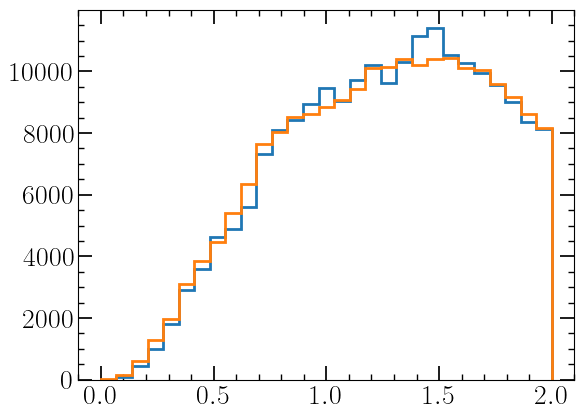

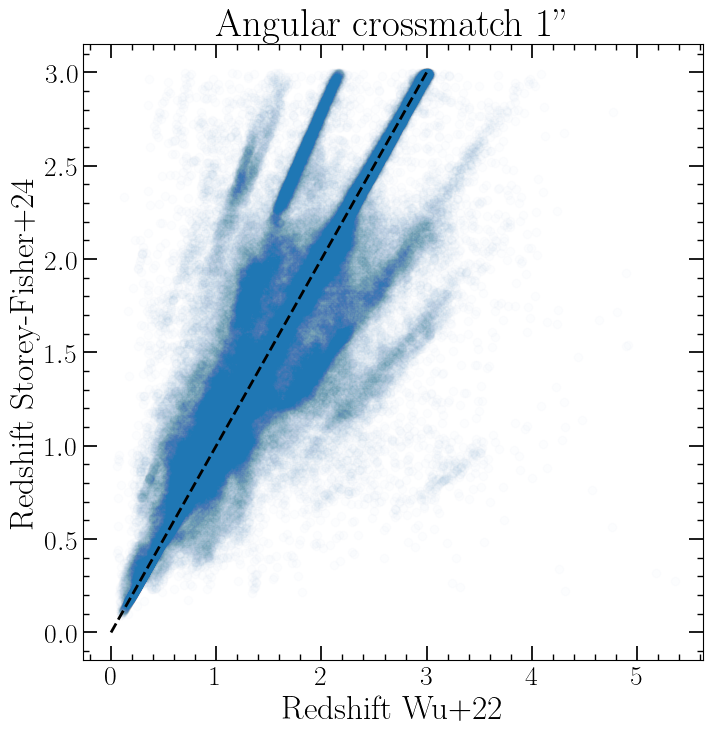

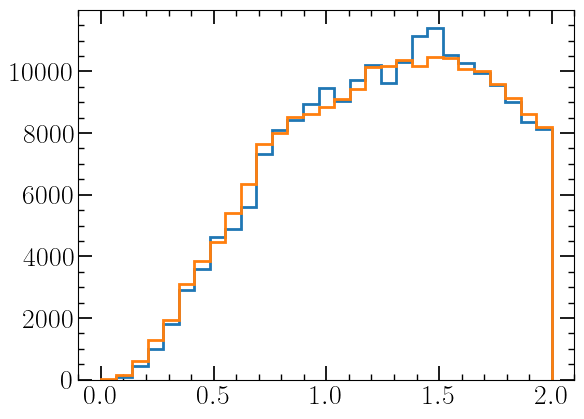

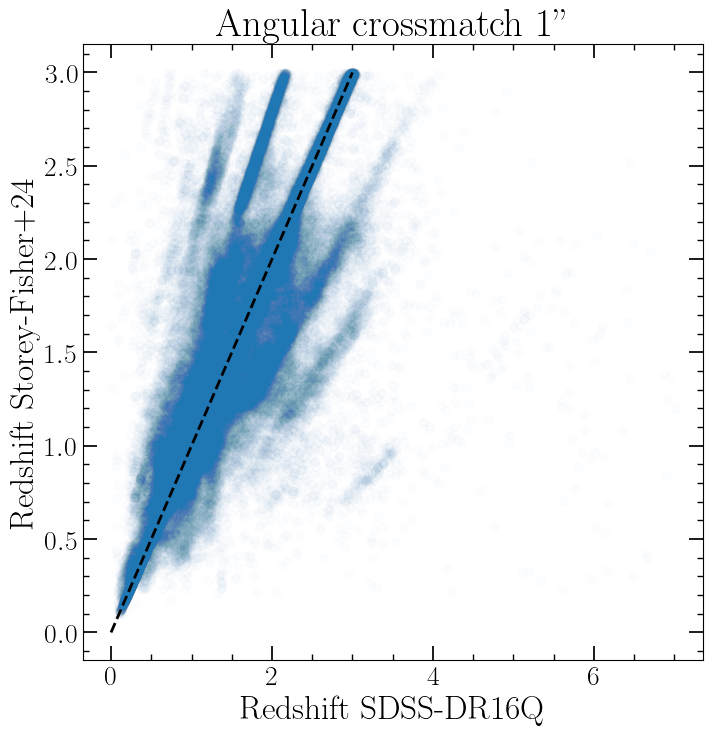

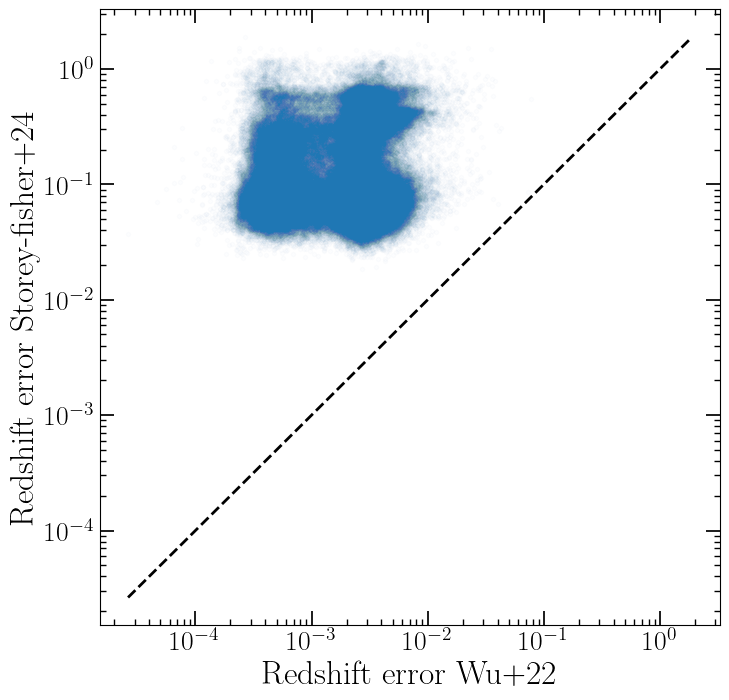

In [11]:
for ztype, label in zip(['Z_SYS', 'Z_DR16Q'], ['Wu+22', 'SDSS-DR16Q']):
    z_sys_match = sdss_match[ztype]
    z_sys_err_match = sdss_match['Z_SYS_ERR']

    z_quaia_match = quaia_match['redshift_quaia'].to_numpy()
    z_err_quaia_match = quaia_match['redshift_quaia_err'].to_numpy()

    mask = (z_sys_match > 0) & (z_sys_err_match > 0)

    edges = np.linspace(0, 2, 30)
    dens = False
    plt.figure()
    plt.hist(z_quaia_match[mask], histtype='step', linewidth=2, bins=edges, density=dens, label='Quaia')
    plt.hist(z_sys_match[mask], histtype='step', linewidth=2, bins=edges, density=dens, label=f'{label} in Quaia')
    # plt.hist(z_sys, histtype='step', linewidth=2, bins=edges, density=dens, label='Wu+22 all')
    # plt.hist(z_sdss, histtype='step', linewidth=2, bins=edges, density=dens, label='SDSS DR16Q all')
    # plt.legend()
    plt.show()

    zz = np.linspace(0, 3, 100)
    plt.figure(figsize=(8, 8))
    plt.scatter(z_sys_match[mask], z_quaia_match[mask], alpha=0.01)
    plt.plot(zz, zz, color='black', linewidth=2, linestyle='dashed')
    plt.xlabel(f'Redshift {label}')
    plt.ylabel('Redshift Storey-Fisher+24')
    plt.title('Angular crossmatch 1"')
    # plt.xlim(0, 0.5)
    # plt.ylim(0, 0.5)
    plt.show()


mask = (sdss_match['Z_SYS'] > 0) & (z_sys_err_match > 0)

ss = np.linspace(np.min(z_sys_err_match[mask]), np.max(z_err_quaia_match[mask]), 100)
plt.figure(figsize=(8, 8))
plt.scatter(z_sys_err_match[mask], z_err_quaia_match[mask], marker='.', alpha=0.01)
plt.plot(ss, ss, color='black', linewidth=2, linestyle='dashed')
plt.loglog()
plt.xlabel('Redshift error Wu+22')
plt.ylabel('Redshift error Storey-fisher+24')
plt.show()


In [12]:
from scipy.optimize import curve_fit

def linear(x, a, b):
    return a * x + b


281785 1468
Median: 0.011109798694320716, Mean: -0.001999743671398065, Standard deviation: 0.20196842793796896
Median: -0.09467453200389997, Mean: -0.10903779441230929, Standard deviation: 0.20355761746025927
[-0.04297071 -0.04156193] [0.00058286 0.00099094]
[-0.04846116  2.13256465] [0.00082362 0.03809883]


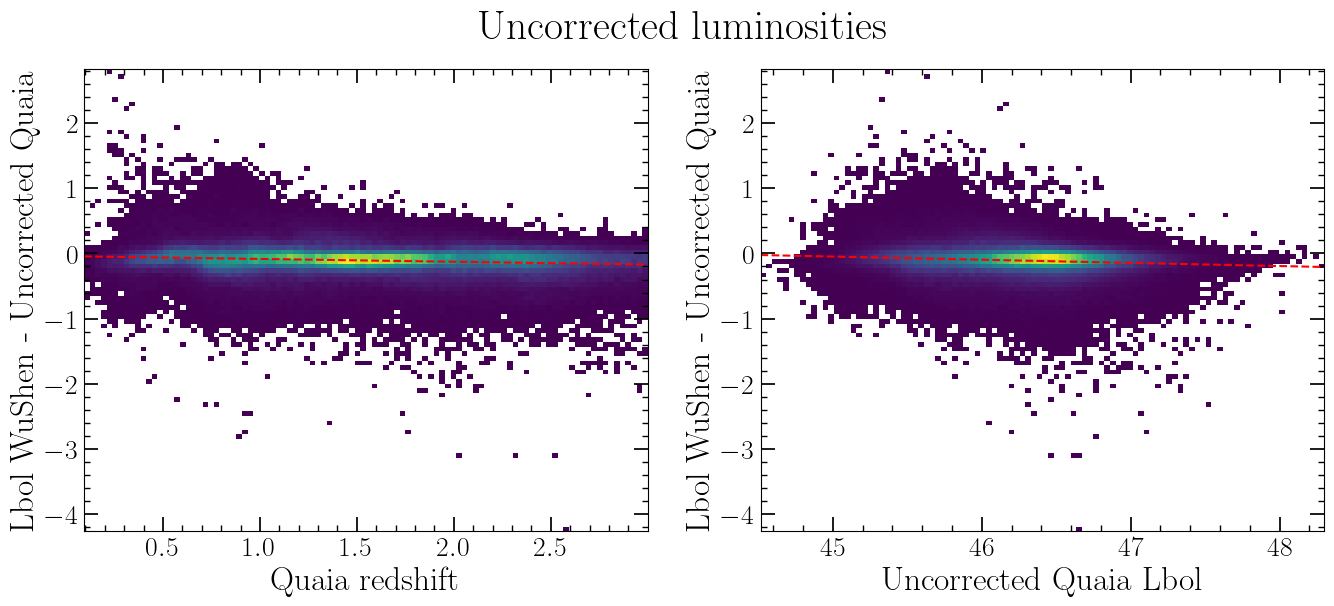

[ 0.00106685 -0.003675  ] [0.00058386 0.00099263]
[-6.19368506e-05  8.65184868e-04] [0.00082219 0.03803291]


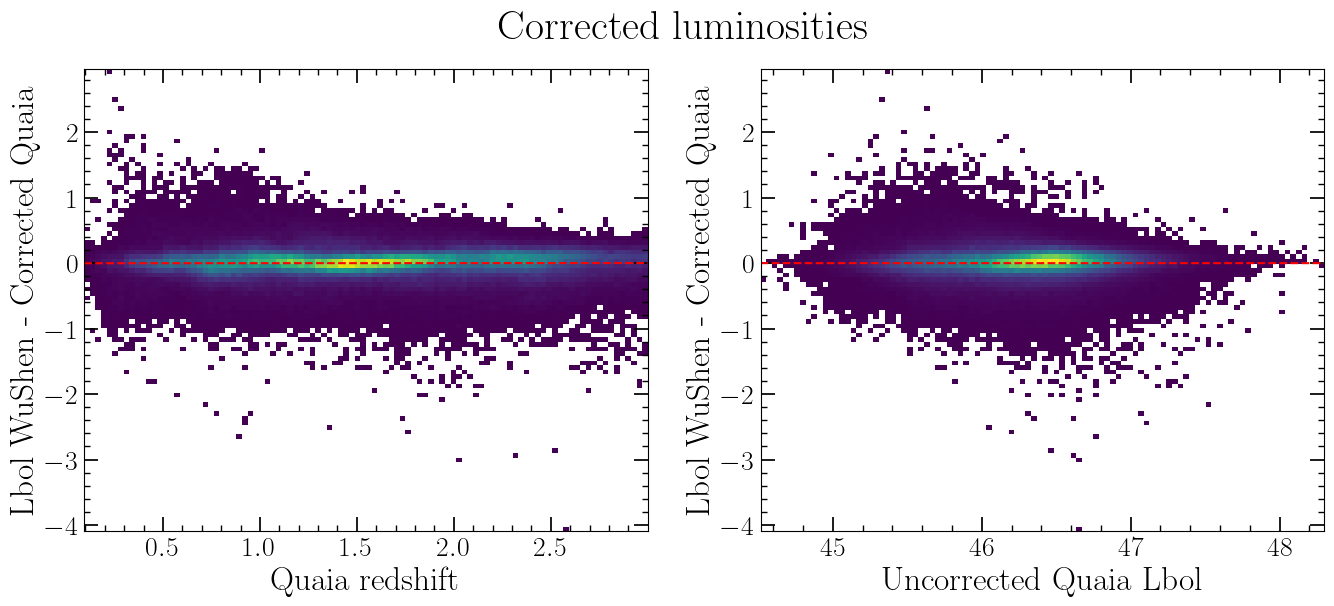

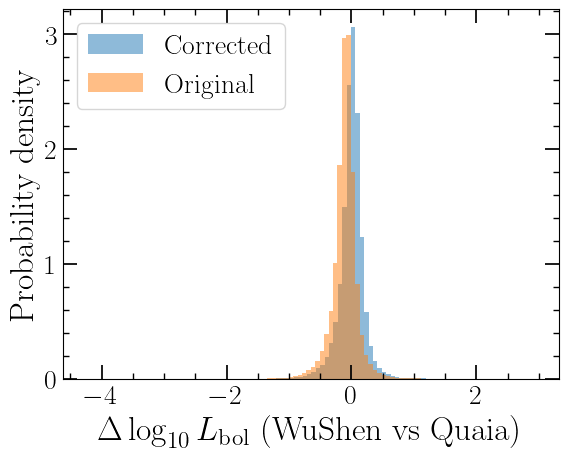

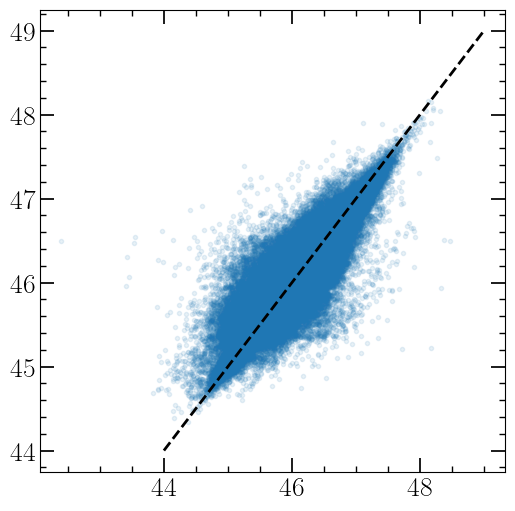

In [13]:
logLbol_sdss = sdss_match['LOGLBOL']
logLbol_err_sdss = sdss_match['LOGLBOL_ERR']
mask = (logLbol_sdss > 0.) & (logLbol_err_sdss > 0.)
print(np.sum(mask), np.sum(~mask))

logLbol_quaia = quaia_match['loglbol_corr'].to_numpy()
logLbol_quaia_uncorrected = quaia_match['log10_bollum'].to_numpy()

diff = (logLbol_sdss - logLbol_quaia)[mask]
print(f'Median: {np.median(diff)}, Mean: {np.mean(diff)}, Standard deviation: {np.std(diff)}')

diff_old = (logLbol_sdss - logLbol_quaia_uncorrected)[mask]
print(f'Median: {np.median(diff_old)}, Mean: {np.mean(diff_old)}, Standard deviation: {np.std(diff_old)}')

# x = np.asarray(quaia_match['redshift_quaia'][mask])
# y = np.asarray(logLbol_quaia_uncorrected[mask])
# c = np.asarray(diff_old)
# randidx = c > -np.inf

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Uncorrected luminosities', fontsize=30)

xdat = quaia_match['redshift_quaia'][mask]
ydat = diff_old
param, pcov = curve_fit(linear, xdat, ydat)
print(param, np.sqrt(np.diag(pcov)))
xax_plot = np.linspace(np.min(xdat), np.max(xdat), 100)
ax1.plot(xax_plot, linear(xax_plot, *param), linestyle='dashed', color='red')

ax1.hist2d(
    xdat,
    diff_old,
    bins=100,
    cmin=1,
    cmap='viridis'
)
ax1.set_ylabel('Lbol WuShen - Uncorrected Quaia')
ax1.set_xlabel('Quaia redshift')

xdat = logLbol_quaia_uncorrected[mask]
ydat = diff_old
param, pcov = curve_fit(linear, xdat, ydat)
print(param, np.sqrt(np.diag(pcov)))
xax_plot = np.linspace(np.min(xdat), np.max(xdat), 100)
ax2.plot(xax_plot, linear(xax_plot, *param), linestyle='dashed', color='red')

ax2.hist2d(
    xdat,
    ydat,
    bins=100,
    cmin=1,
    cmap='viridis'
)
ax2.set_ylabel('Lbol WuShen - Uncorrected Quaia')
ax2.set_xlabel('Uncorrected Quaia Lbol')
plt.show()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Corrected luminosities', fontsize=30)

xdat = quaia_match['redshift_quaia'][mask]
ydat = diff
param, pcov = curve_fit(linear, xdat, ydat)
print(param, np.sqrt(np.diag(pcov)))
xax_plot = np.linspace(np.min(xdat), np.max(xdat), 100)
ax1.plot(xax_plot, linear(xax_plot, *param), linestyle='dashed', color='red')

ax1.hist2d(
    xdat,
    ydat,
    bins=100,
    cmin=1,
    cmap='viridis'
)
ax1.set_ylabel('Lbol WuShen - Corrected Quaia')
ax1.set_xlabel('Quaia redshift')

xdat = logLbol_quaia_uncorrected[mask]
ydat = diff
param, pcov = curve_fit(linear, xdat, ydat)
print(param, np.sqrt(np.diag(pcov)))
xax_plot = np.linspace(np.min(xdat), np.max(xdat), 100)
ax2.plot(xax_plot, linear(xax_plot, *param), linestyle='dashed', color='red')

ax2.hist2d(
    xdat,
    ydat,
    bins=100,
    cmin=1,
    cmap='viridis'
)
ax2.set_ylabel('Lbol WuShen - Corrected Quaia')
ax2.set_xlabel('Uncorrected Quaia Lbol')
plt.show()


# plt.figure()
# # plt.scatter(quaia_match['redshift_quaia'][mask], diff, label='Corrected', marker='.', alpha=0.01)
# plt.scatter(quaia_match['redshift_quaia'][mask], diff_old, label='Original', marker='.', alpha=0.01)
# plt.legend()
# plt.xlabel('Quaia redshift')
# plt.show()

# plt.figure()
# # plt.scatter(logLbol_quaia_uncorrected[mask], diff, label='Corrected', marker='.', alpha=0.01)
# plt.scatter(logLbol_quaia_uncorrected[mask], diff_old, label='Original', marker='.', alpha=0.01)
# plt.legend()
# plt.xlabel('Quaia Lbol')
# plt.show()


plt.figure()
plt.hist(diff, bins=100, density=True, label='Corrected', alpha=0.5)
plt.hist(diff_old, bins=100, density=True, label='Original', alpha=0.5)
plt.xlabel(r'$\Delta \log_{10} L_{\rm bol}$ (WuShen vs Quaia)')
plt.ylabel('Probability density')
plt.legend()
plt.show()

ll = np.linspace(44, 49, 100)
plt.figure(figsize=(6,6))
plt.scatter(logLbol_sdss[mask], logLbol_quaia[mask], marker='.', alpha=0.1)
plt.plot(ll, ll, color='black', linestyle='dashed', linewidth=2)
plt.show()

# plt.figure()
# plt.hist(logLbol_err_sdss[mask], bins=100, density=True)
# # plt.xlabel(r'$\Delta \log_{10} L_{\rm bol}$')
# plt.ylabel('Probability density')
# plt.show()


# Try different corrections: fit plane through point cloud

f(x,y) = -0.02051 + -0.04271 x + -0.000464 y
RMS residual = 0.2016


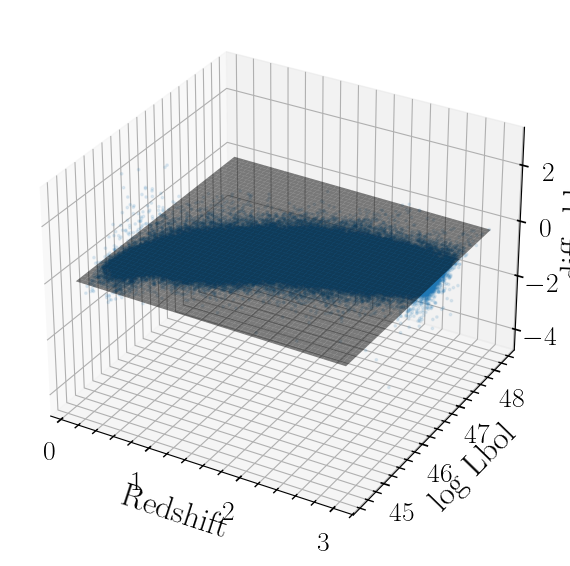

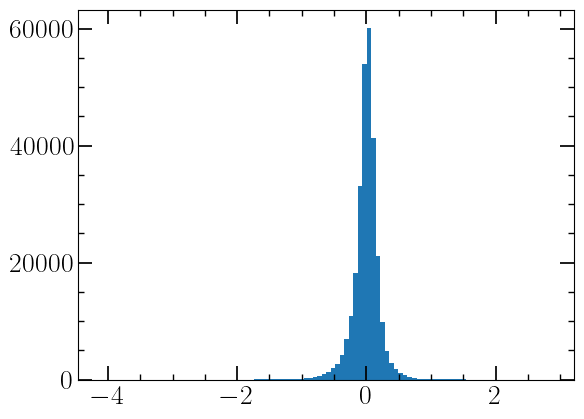

0.013657162336471379 1.1038457973502544e-15 0.2016223759566927


In [14]:
import numpy as np
import matplotlib.pyplot as plt

x = np.asarray(quaia_match['redshift_quaia'])[mask]
y = np.asarray(logLbol_quaia_uncorrected)[mask]
z = np.asarray(diff_old)

# Remove NaNs/infs
good = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

x_fit = x[good]
y_fit = y[good]
z_fit = z[good]

# Design matrix: constant, x, y
A = np.column_stack([
    np.ones(len(x_fit)),
    x_fit,
    y_fit
])

# Fit z = a + b*x + c*y
coeff, residuals, rank, s = np.linalg.lstsq(A, z_fit, rcond=None)

a, b, c = coeff

print(f"f(x,y) = {a:.4g} + {b:.4g} x + {c:.4g} y")

z_pred = a + b*x_fit + c*y_fit
residual = z_fit - z_pred

print(f"RMS residual = {np.std(residual):.4g}")

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Data
ax.scatter(
    x_fit, y_fit, z_fit,
    s=3,
    alpha=0.1
)

# Plane
xx = np.linspace(x_fit.min(), x_fit.max(), 50)
yy = np.linspace(y_fit.min(), y_fit.max(), 50)
XX, YY = np.meshgrid(xx, yy)

ZZ = a + b*XX + c*YY

ax.plot_surface(
    XX, YY, ZZ,
    alpha=0.5,
    color='black'
)

ax.set_xlabel('Redshift')
ax.set_ylabel('log Lbol')
ax.set_zlabel('diff_old')

plt.show()

z_plane = a + b*x + c*y
z_residual = z - z_plane

plt.figure()
plt.hist(z_residual, bins=100)
plt.show()

print(np.median(z_residual), np.mean(z_residual), np.std(z_residual))


# Check plane fit through point cloud

In [15]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "browser"

# Data
x = np.asarray(quaia_match['redshift_quaia'])[mask]
y = np.asarray(logLbol_quaia_uncorrected)[mask]
z = np.asarray(diff_old)

# Remove NaNs / infs
good = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

x_fit = x[good]
y_fit = y[good]
z_fit = z[good]

# Fit plane: z = a + b*x + c*y
A = np.column_stack([
    np.ones(len(x_fit)),
    x_fit,
    y_fit
])

a, b, c = np.linalg.lstsq(A, z_fit, rcond=None)[0]

print(f"Plane: z = {a:.4f} + {b:.4f} x + {c:.4f} y")

# Grid for plane
xx = np.linspace(x_fit.min(), x_fit.max(), 50)
yy = np.linspace(y_fit.min(), y_fit.max(), 50)
XX, YY = np.meshgrid(xx, yy)

ZZ = a + b * XX + c * YY

# Interactive figure
fig = go.Figure()

# Data
fig.add_trace(go.Scatter3d(
    x=x_fit,
    y=y_fit,
    z=z_fit,
    mode='markers',
    name='Data',
    marker=dict(
        size=3,
        color='blue',
        opacity=0.05
    )
))

# Fitted plane
fig.add_trace(go.Surface(
    x=XX,
    y=YY,
    z=ZZ,
    name='Best-fit plane',
    opacity=0.5,
    showscale=False
))

fig.update_layout(
    scene=dict(
        xaxis_title='Redshift',
        yaxis_title='log Lbol',
        zaxis_title='diff_old'
    ),
    title='Linear plane fit to diff_old'
)

fig.show()

Plane: z = -0.0205 + -0.0427 x + -0.0005 y


Gtk-Message: 13:59:01.566: Not loading module "atk-bridge": The functionality is provided by GTK natively. Please try to not load it.


# Apply correction and check result

Niccos correction: 0.011109798694320716 -0.001999743671398065 0.20196842793796896
My correction: 0.013657162336471629 -1.36518209677775e-16 0.2016223759566927


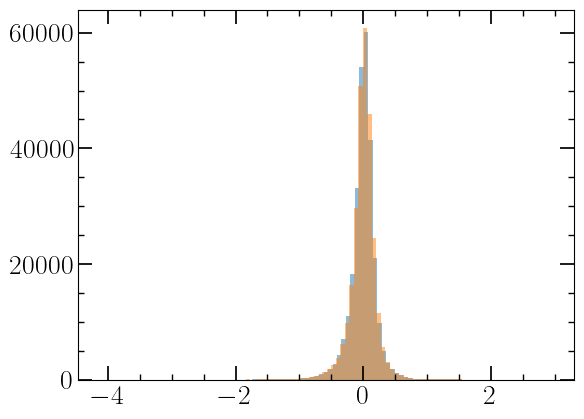

[-4.24393853e-11  6.84335921e-11] [8.78542108e-05 1.43963580e-04]
[-1.01048858e-09  4.68718960e-08] [0.00048836 0.02259102]


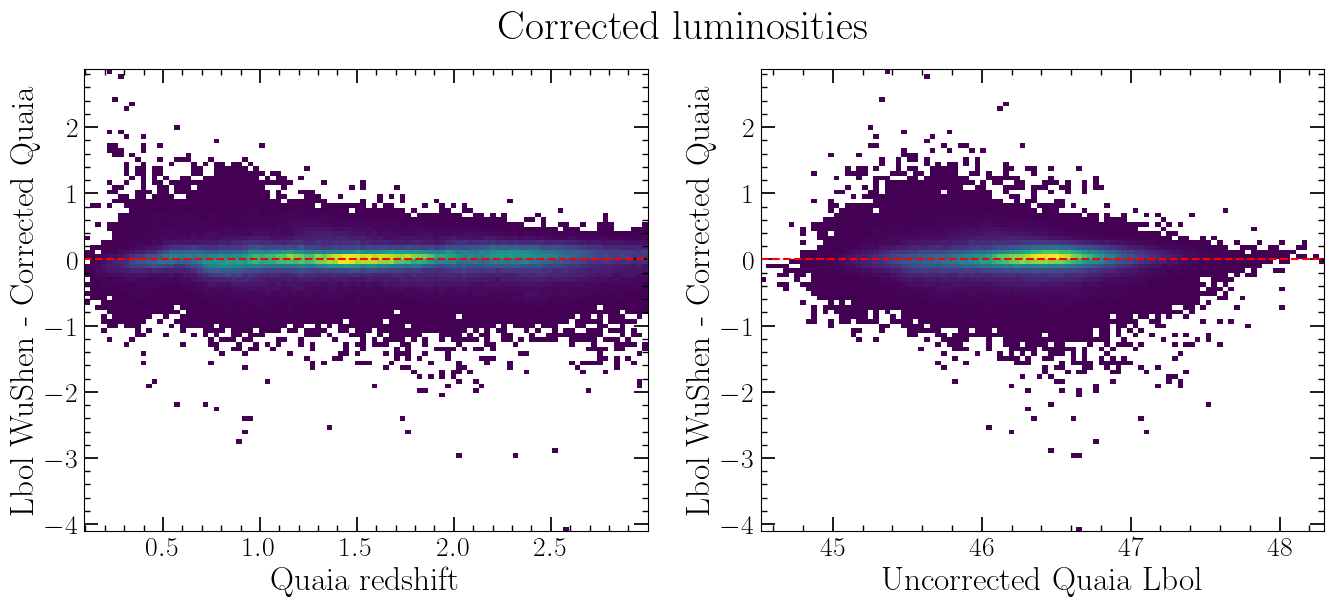

In [16]:
xdat = np.asarray(quaia_match['redshift_quaia'])[mask]
ydat = np.asarray(logLbol_quaia_uncorrected)[mask]

new_corrected_Lbol_quaia = ydat + a + b*xdat + c*ydat
new_diff = logLbol_sdss[mask] - new_corrected_Lbol_quaia
print('Niccos correction:', np.median(diff), np.mean(diff), np.std(diff))
print('My correction:', np.median(new_diff), np.mean(new_diff), np.std(new_diff))

plt.figure()
plt.hist(new_diff, bins=100, alpha=0.5)
plt.hist(diff, bins=100, alpha=0.5)
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Corrected luminosities', fontsize=30)

xdat = quaia_match['redshift_quaia'][mask]
ydat = new_diff
param, pcov = curve_fit(linear, xdat, ydat)
print(param, np.sqrt(np.diag(pcov)))
xax_plot = np.linspace(np.min(xdat), np.max(xdat), 100)
ax1.plot(xax_plot, linear(xax_plot, *param), linestyle='dashed', color='red')

ax1.hist2d(
    xdat,
    ydat,
    bins=100,
    cmin=1,
    cmap='viridis'
)
ax1.set_ylabel('Lbol WuShen - Corrected Quaia')
ax1.set_xlabel('Quaia redshift')

xdat = logLbol_quaia_uncorrected[mask]
ydat = new_diff
param, pcov = curve_fit(linear, xdat, ydat)
print(param, np.sqrt(np.diag(pcov)))
xax_plot = np.linspace(np.min(xdat), np.max(xdat), 100)
ax2.plot(xax_plot, linear(xax_plot, *param), linestyle='dashed', color='red')

ax2.hist2d(
    xdat,
    ydat,
    bins=100,
    cmin=1,
    cmap='viridis'
)
ax2.set_ylabel('Lbol WuShen - Corrected Quaia')
ax2.set_xlabel('Uncorrected Quaia Lbol')
plt.show()


# Does my method result in a different catalogue than Nicco's?

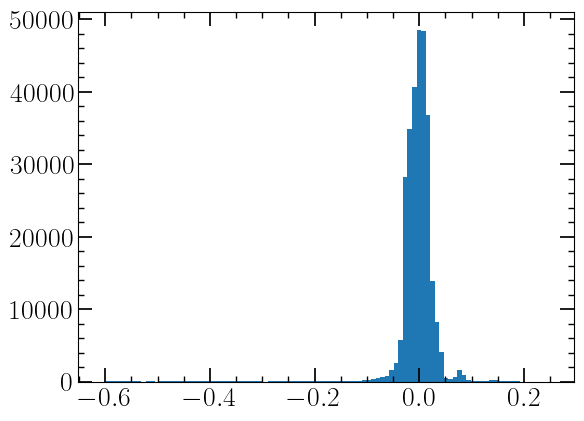

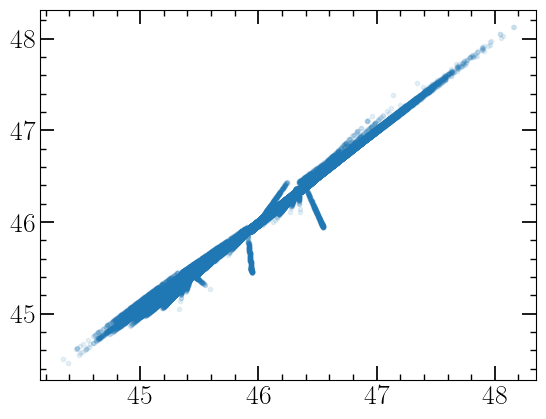

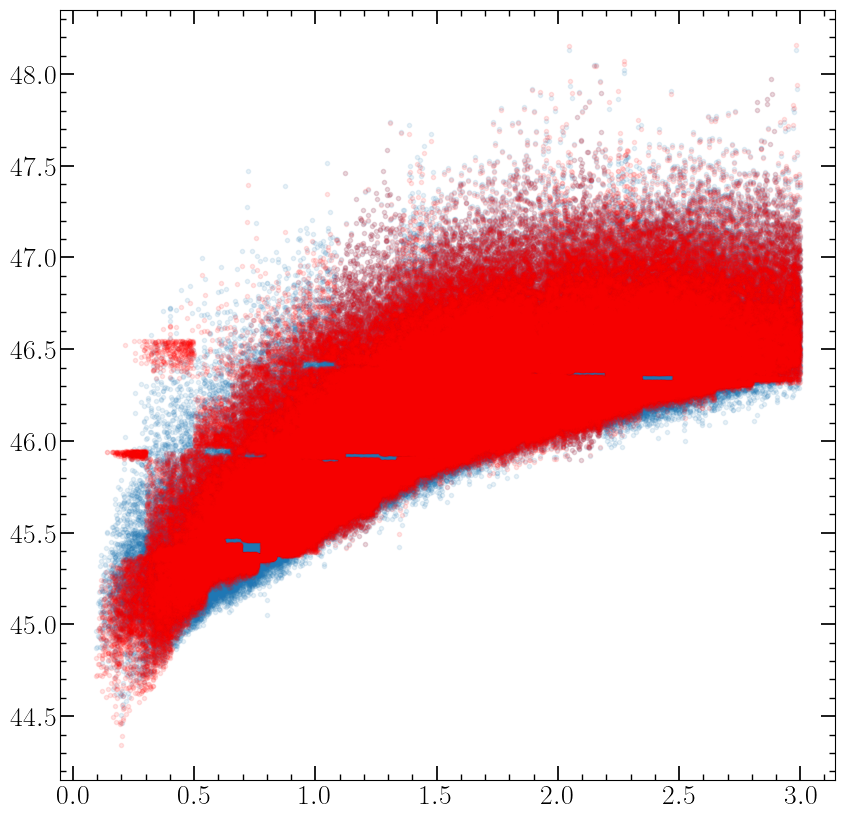

In [17]:
p26_vs_v25 = new_corrected_Lbol_quaia - logLbol_quaia[mask]

plt.figure()
plt.hist(p26_vs_v25, bins=100)
plt.show()

plt.figure()
plt.scatter(logLbol_quaia[mask], new_corrected_Lbol_quaia, marker='.', alpha=0.1)
plt.show()

plt.figure(figsize=(10,10))
plt.scatter(quaia_match['redshift_quaia'][mask], new_corrected_Lbol_quaia, marker='.', alpha=0.1)
plt.scatter(quaia_match['redshift_quaia'][mask], logLbol_quaia[mask], marker='.', alpha=0.1, color='red')
plt.show()


# Apply correction to full dataset and store

In [ ]:
df = pd.read_csv("/home/lucas/Documents/PhD/agn_data/quaia_zleq3_withlumcorr.csv")

xdat = np.asarray(df['redshift_quaia'])
ydat = np.asarray(df['log10_bollum'])

df["loglbol_corr_smooth"] = ydat + a + b*xdat + c*ydat

# Save as a new file
# df.to_csv("/home/lucas/Documents/PhD/agn_data/quaia_zleq3_withlumcorr_smooth.csv", index=False)


# Comparison of the full catalogue

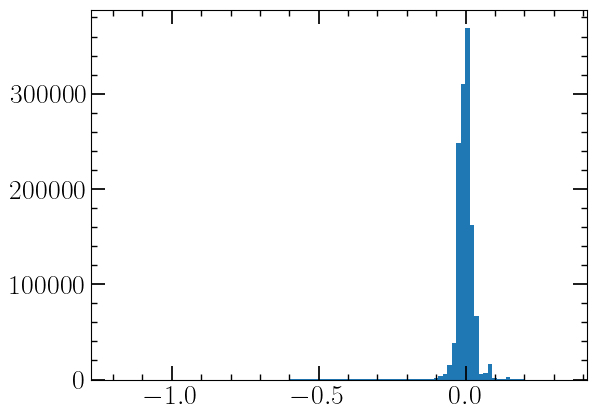

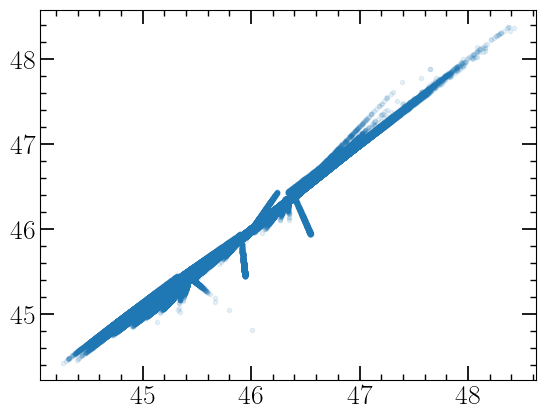

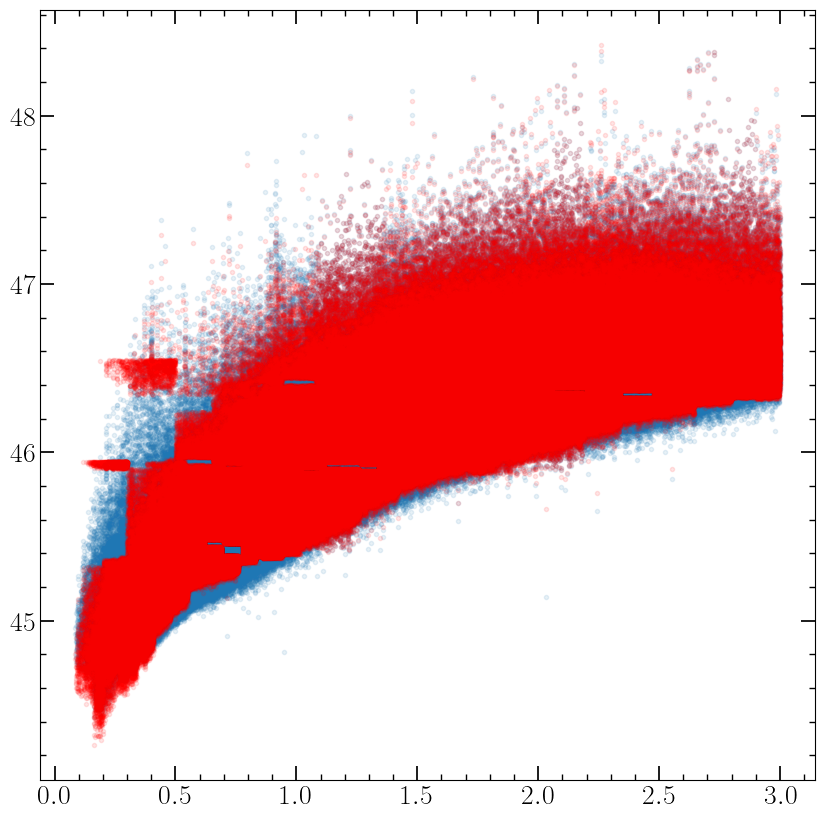

In [20]:
p26_vs_v25 = df["loglbol_corr_smooth"] - df['loglbol_corr']

plt.figure()
plt.hist(p26_vs_v25, bins=100)
plt.show()

plt.figure()
plt.scatter(df['loglbol_corr'], df["loglbol_corr_smooth"], marker='.', alpha=0.1)
plt.show()

plt.figure(figsize=(10,10))
plt.scatter(xdat, df["loglbol_corr_smooth"], marker='.', alpha=0.1)
plt.scatter(xdat, df['loglbol_corr'], marker='.', alpha=0.1, color='red')
plt.show()


In [19]:
# print(f'{np.log10((5100 * u.angstrom).to(u.Hz, equivalencies=u.spectral()).value):.2f}')
# print(f'{np.log10((3000 * u.angstrom).to(u.Hz, equivalencies=u.spectral()).value):.2f}')
# print(f'{np.log10((1350 * u.angstrom).to(u.Hz, equivalencies=u.spectral()).value):.2f}')

# N = int(1e6)
# lbolcorr = 1.5
# lbolcorr_err = 0.2
# bolcorrs = np.random.normal(lbolcorr, lbolcorr_err, size=N)
# bolcorrs = bolcorrs[bolcorrs > 0]

# log10_l_center = 42
# plt.figure()
# plt.hist(np.log10(10**log10_l_center * bolcorrs), bins=50)
# plt.show()

# print(np.std(np.log10(10**log10_l_center * bolcorrs)))
